In [4]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers.legacy import Adam

from keras import metrics
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score
from qiskit.quantum_info import SparsePauliOp
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches
import seaborn as sns

import medmnist
from medmnist import INFO, Evaluator

# Load Data set

In [5]:
n_epochs = 40   # Number of optimization epochs
n_layers = 1    # Number of random layers
n_train = 546   # Size of the train dataset
n_test = 156    # Size of the test dataset
n_val = 78    # Size of the val dataset
learning_rate = 0.1

SAVE_PATH = "Breast_2x2_Ryd/" # Data saving folder
PREPROCESS =  True # False        # If False, skip quantum processing and load data from SAVE_PATH
np.random.seed(40)           # Seed for NumPy random number generator
tf.random.set_seed(40)       # Seed for TensorFlow random number generator

In [6]:
data_flag = 'breastmnist' # 'pneumoniamnist' 'pathmnist', 'retinamnist'

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist,info['python_class'])

print('The number of classe are: ', n_classes,'\nAnd the number of channels: ', n_channels, '\nAnd the task is: ',task)

The number of classe are:  2 
And the number of channels:  1 
And the task is:  binary-class


In [8]:
# load the data
train_dataset = DataClass(split='train', download=True)
test_dataset = DataClass(split='test', download=True)
val_dataset = DataClass(split='val', download=True)

# Reshape the images
train_imgs_tf = np.reshape(train_dataset.imgs, (n_train,28,28,1))
test_imgs_tf = np.reshape(test_dataset.imgs, (n_test,28,28,1))
val_imgs_tf = np.reshape(val_dataset.imgs, (n_val,28,28,1))

# Load the labels
train_labels_tf = np.reshape(train_dataset.labels, (n_train,))
test_labels_tf = np.reshape(test_dataset.labels, (n_test,))
val_labels_tf = np.reshape(val_dataset.labels, (n_val,))

# Reduce dataset size
train_imgs_tf = train_imgs_tf[:n_train]
train_labels_tf = train_labels_tf[:n_train]
test_imgs_tf = test_imgs_tf[:n_test]
test_labels_tf = test_labels_tf[:n_test]
val_imgs_tf = val_imgs_tf[:n_val]
val_labels_tf = val_labels_tf[:n_val]

# Normalize pixel values within 0 and 1
train_imgs_tf = (train_imgs_tf / 255)*np.pi
test_imgs_tf = (test_imgs_tf / 255)*np.pi
val_imgs_tf = (val_imgs_tf / 255)*np.pi

RuntimeError: 
                Automatic download failed! Please download breastmnist.npz manually.
                1. [Optional] Check your network connection: 
                    Go to https://github.com/MedMNIST/MedMNIST/ and find the Zenodo repository
                2. Download the npz file from the Zenodo repository or its Zenodo data link: 
                    https://zenodo.org/records/10519652/files/breastmnist.npz?download=1
                3. [Optional] Verify the MD5: 
                    750601b1f35ba3300ea97c75c52ff8f6
                4. Put the npz file under your MedMNIST root folder: 
                    /home/maloto3/.medmnist
                

In [ ]:
train_imgs_tf.shape

## Let's see a little bit more in depth the data set

In [6]:
def plot_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_classes, counts)
    plt.title(f'Class Distribution in {dataset_name} Set')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

def print_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    total_samples = len(labels)
    class_percentages = counts / total_samples * 100

    print(f'Class Distribution in {dataset_name} Set:')
    for cls, percentage in zip(unique_classes, class_percentages):
        print(f'Class {cls}: {percentage:.2f}%')


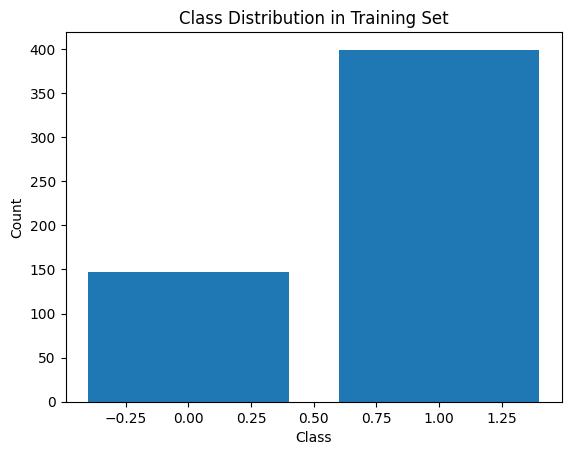

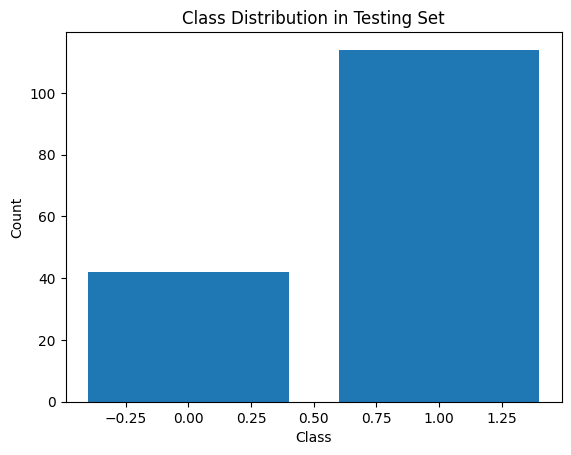

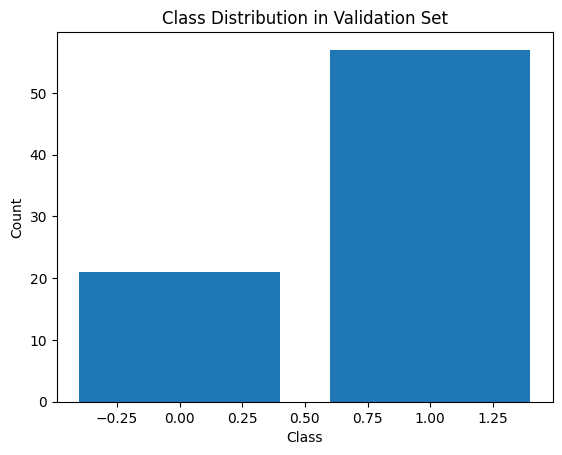

Class Distribution in Training Set:
Class 0: 26.92%
Class 1: 73.08%
Class Distribution in Testing Set:
Class 0: 26.92%
Class 1: 73.08%
Class Distribution in Validation Set:
Class 0: 26.92%
Class 1: 73.08%


In [7]:
plot_class_distribution(train_labels_tf, 'Training')
plot_class_distribution(test_labels_tf, 'Testing')
plot_class_distribution(val_labels_tf, 'Validation')
print_class_distribution(train_labels_tf, 'Training')
print_class_distribution(test_labels_tf, 'Testing')
print_class_distribution(val_labels_tf, 'Validation')

# Different Quantum circuits Entangling

In [9]:
n_qubits = 4
graphs = {
    
    "king" : [[0,1], [0,2], [0,3], [1,2], [1,3], [2,3]],
    "closed-nn" : [[0,1], [1,3], [3,2], [2,0]],
    "open-nn": [[1,0],[0,2],[2,3]],
    "gamma": [[0,3],[3,2],[2,1]]
    
}

# FOR 3X3 KERNELS, UNCOMMENT THE BELLOW DICTIONARY

"""

graphs = {
   
    "king" : [[0,1],[0,3],[0,4],[1,2],[1,3],[1,4],[1,5],[2,3],[2,4],[3,4],[3,6],[3,7],[4,5],[4,6],[4,7],[4,8],[5,7],[5,8],[6,7],[7,8]]
     
}

"""

'\n\ngraphs = {\n   \n    "king" : [[0,1],[0,3],[0,4],[1,2],[1,3],[1,4],[1,5],[2,3],[2,4],[3,4],[3,6],[3,7],[4,5],[4,6],[4,7],[4,8],[5,7],[5,8],[6,7],[7,8]]\n     \n}\n\n'

## Let's define the 4 possible circuits

In [13]:
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

## KING

In [14]:
@qml.qnode(dev, interface="autograd")
def king_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["king"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

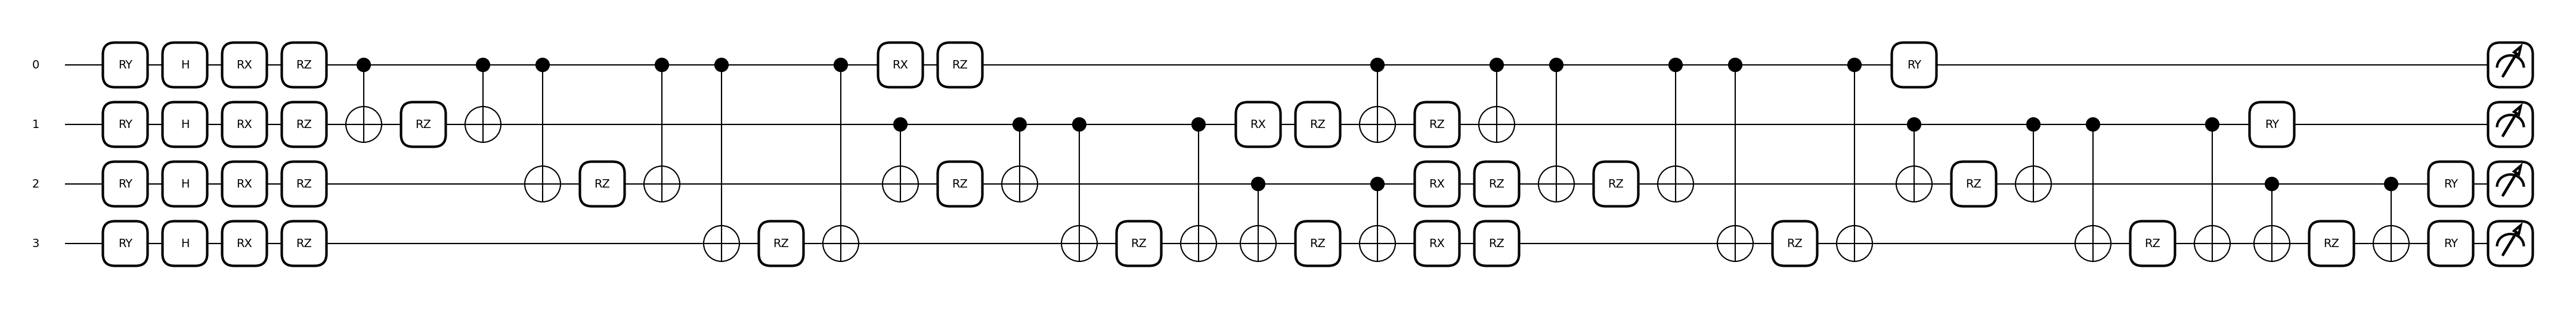

In [15]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(king_circuit, max_length=60)('params')
plt.show()

## Closed

In [16]:
@qml.qnode(dev, interface="autograd")
def closed_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["closed-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

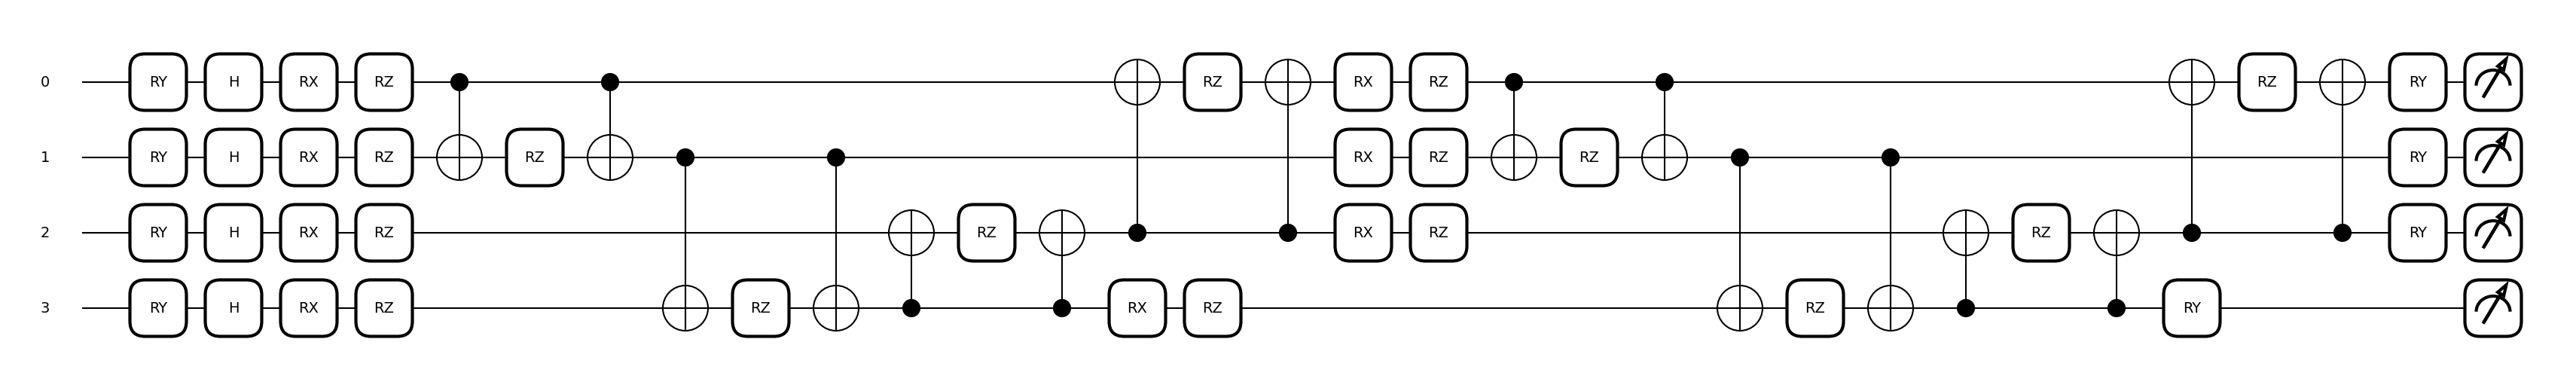

In [17]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(closed_circuit, max_length=60)('params')
plt.show()

## Opened

In [19]:
@qml.qnode(dev, interface="autograd")
def open_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["open-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

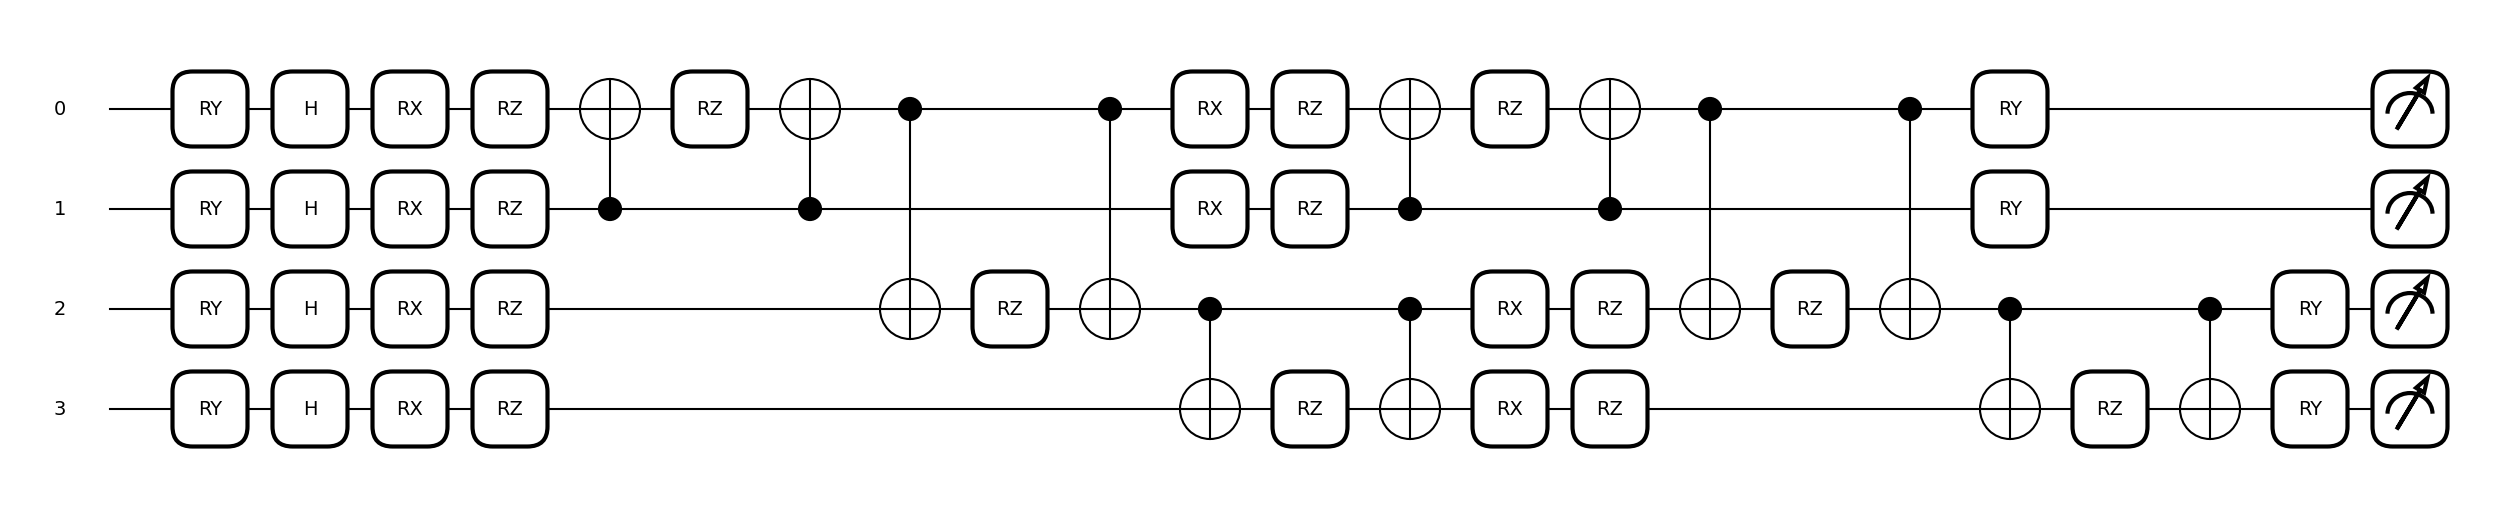

In [20]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(open_circuit, max_length=60)('params')
plt.show()

## Gamma

In [21]:
@qml.qnode(dev, interface="autograd")
def gamma_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["gamma"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

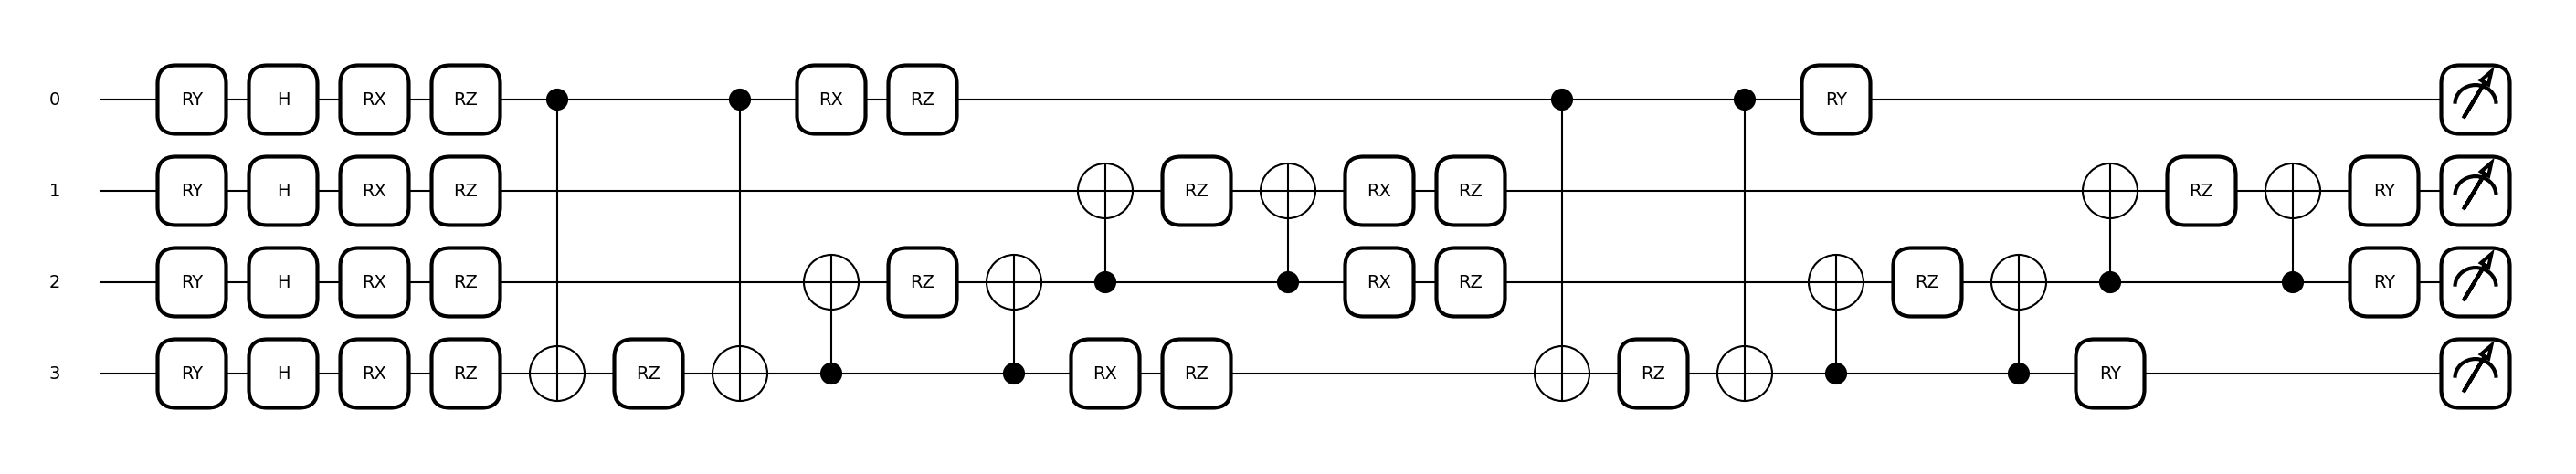

In [22]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(gamma_circuit, max_length=60)('params')
plt.show()

# Let's define the quanvolution

In [111]:
def quanv(image):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((27, 27, 16))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, 27, 1):
        for k in range(0, 27, 1):
            # Process a squared 2x2 region of the image with a quantum circuit
            q1_results = king_circuit( # circuit 1
                [
                    image[j, k, 0],
                    image[j, k + 1, 0],
                    image[j + 1, k, 0],
                    image[j + 1, k + 1, 0]
                ]
            )
            
            q2_results = closed_circuit( # circuit 2
                [
                    image[j, k, 0],
                    image[j, k + 1, 0],
                    image[j + 1, k, 0],
                    image[j + 1, k + 1, 0]
                ]
            )
            q3_results = open_circuit( # circuit 3
                [
                    image[j, k, 0],
                    image[j, k + 1, 0],
                    image[j + 1, k, 0],
                    image[j + 1, k + 1, 0]
                ]
            )
            
            q4_results = gamma_circuit( # circuit 4
                [
                    image[j, k, 0],
                    image[j, k + 1, 0],
                    image[j + 1, k, 0],
                    image[j + 1, k + 1, 0]
                ]
            )
            # Assign expectation values to different channels of the output pixel (j/2, k/2)
            for c in range(4): 
                out[j, k, c] = q1_results[c]
            for c in range(4):
                out[j, k, c+4] = q2_results[c]
            for c in range(4): 
                out[j, k, c+8] = q3_results[c]
            for c in range(4):
                out[j, k, c+12] = q4_results[c]
    return out

In [112]:
SAVE_PATH = "kernel_2x2_4_circuits_all_qubits/"
if PREPROCESS == True: 
    # PROCCESS TRAIN DATA SET
    q_train_images = []
    print("Quantum pre-processing of train images:")
    for idx, img in enumerate(train_imgs_tf):
        print("{}/{}        ".format(idx + 1, n_train), end="\r")
        q_train_images.append(quanv(img))
    q_train_images = np.asarray(q_train_images)
    
    # PROCCESS TEST DATA SET
    q_test_images = []
    print("\nQuantum pre-processing of test images:")
    for idx, img in enumerate(test_imgs_tf):
        print("{}/{}        ".format(idx + 1, n_test), end="\r")
        q_test_images.append(quanv(img))
    q_test_images = np.asarray(q_test_images)
    
    # PROCCESS VALIDATION DATA SET
    q_val_images = []
    print("\nQuantum pre-processing of val images:")
    for idx, img in enumerate(val_imgs_tf):
        print("{}/{}        ".format(idx + 1, n_val), end="\r")
        q_val_images.append(quanv(img))
    q_val_images = np.asarray(q_val_images)

Quantum pre-processing of train images:
546/546        
Quantum pre-processing of test images:
156/156        
Quantum pre-processing of val images:


In [117]:
# Save pre-processed images
np.save(SAVE_PATH + "q_train_images.npy", q_train_images)
np.save(SAVE_PATH + "q_test_images.npy", q_test_images)
np.save(SAVE_PATH + "q_val_images.npy", q_val_images)

In [118]:
q_train_images = np.load(SAVE_PATH + "q_train_images.npy")
q_test_images = np.load(SAVE_PATH + "q_test_images.npy")
q_val_images = np.load(SAVE_PATH + "q_val_images.npy")

# Let's see the ressultant images

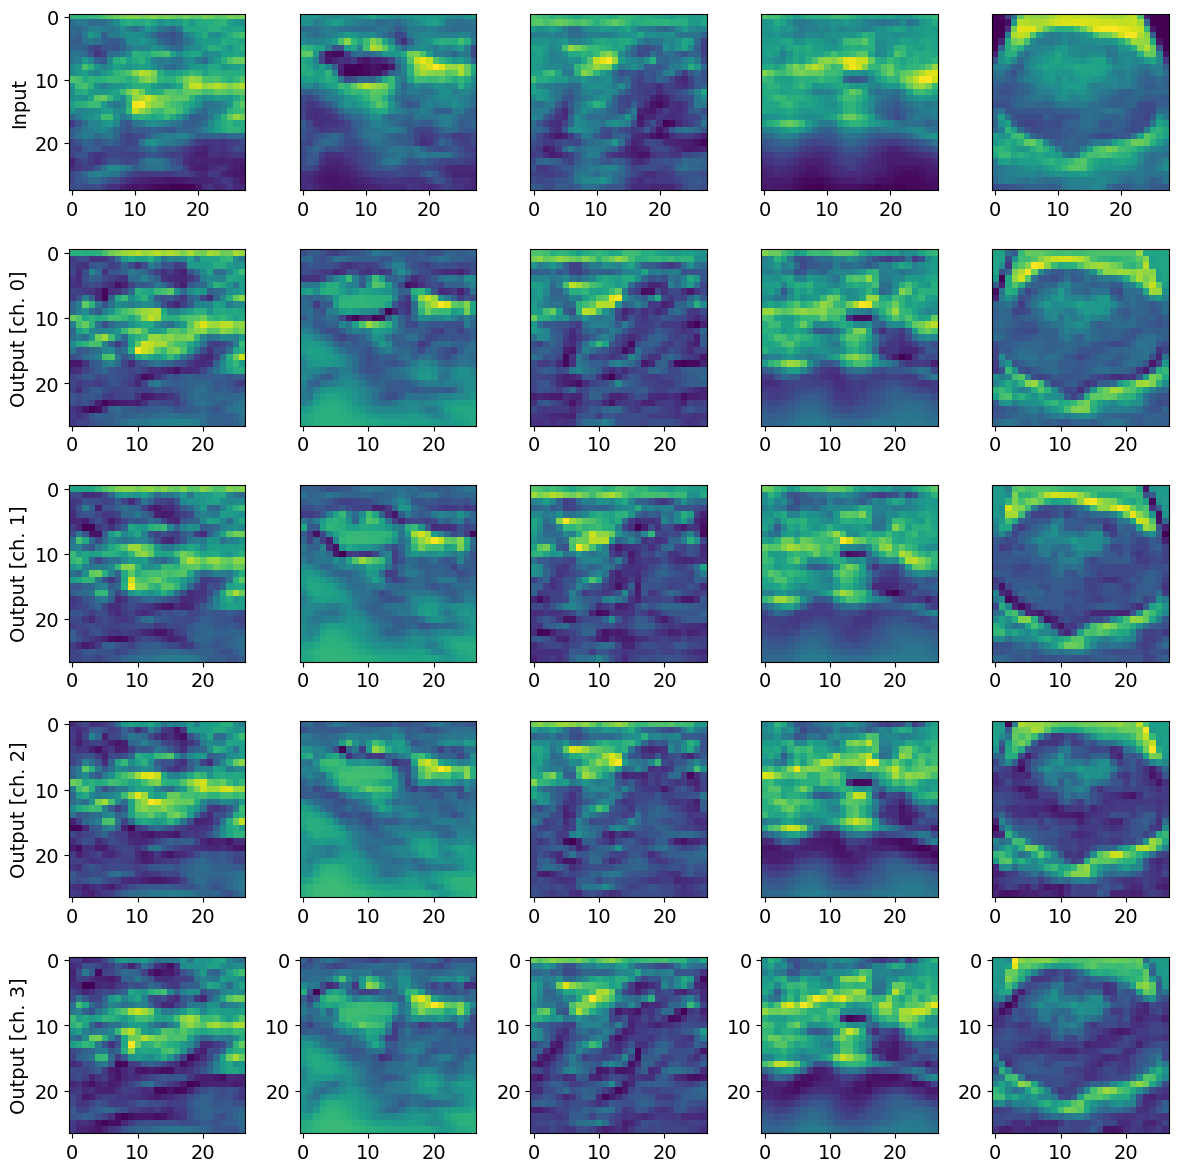

In [175]:
# PRINT SOME SAMPLES
n_samples = 5
n_channels = 4
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf[k, :, :, 0])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, :, c])

plt.tight_layout()
plt.show()

# Creating models with 1 output

In [224]:
def CNN(learning_rate = 0.0005):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv2D(18, (2,2), strides = 1, activation='relu', input_shape=(28,28,1)),
        keras.layers.BatchNormalization(momentum=0.98),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(14, (2, 2), strides = 1, activation='relu'),
        keras.layers.BatchNormalization(momentum=0.98),
        keras.layers.Dropout(.3),
        keras.layers.Flatten(),
        keras.layers.Dropout(.3),
        keras.layers.Dense(2, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate, decay = 1e-06),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        
    )
    return model


def qcnn(learning_rate, activation, dropout, decay):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv2D(64, (2,2), strides = 1, activation=activation, input_shape=(27,27,16), trainable=True),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(64, (2,2), strides = 1, activation=activation, trainable=True),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate, decay = decay),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return model

In [225]:
q_model = qcnn(learning_rate = 0.0005, activation = 'relu', dropout = 0.55, decay = 1e-07)
 
q_history = q_model.fit(
    q_train_images,
    train_labels_tf,
    validation_data=(q_val_images, val_labels_tf),
    batch_size=8,
    epochs=100,
    verbose=2
)

Epoch 1/100
69/69 - 1s - loss: 0.8732 - binary_accuracy: 0.6630 - val_loss: 0.5339 - val_binary_accuracy: 0.8333 - 869ms/epoch - 13ms/step
Epoch 2/100
69/69 - 0s - loss: 0.6345 - binary_accuracy: 0.7216 - val_loss: 0.4342 - val_binary_accuracy: 0.8205 - 413ms/epoch - 6ms/step
Epoch 3/100
69/69 - 0s - loss: 0.5379 - binary_accuracy: 0.7674 - val_loss: 0.4402 - val_binary_accuracy: 0.7692 - 399ms/epoch - 6ms/step
Epoch 4/100
69/69 - 0s - loss: 0.4627 - binary_accuracy: 0.7949 - val_loss: 0.4809 - val_binary_accuracy: 0.8077 - 427ms/epoch - 6ms/step
Epoch 5/100
69/69 - 0s - loss: 0.4639 - binary_accuracy: 0.7967 - val_loss: 0.4486 - val_binary_accuracy: 0.8590 - 419ms/epoch - 6ms/step
Epoch 6/100
69/69 - 0s - loss: 0.4122 - binary_accuracy: 0.8187 - val_loss: 0.3827 - val_binary_accuracy: 0.8590 - 425ms/epoch - 6ms/step
Epoch 7/100
69/69 - 0s - loss: 0.3851 - binary_accuracy: 0.8297 - val_loss: 0.4511 - val_binary_accuracy: 0.8590 - 410ms/epoch - 6ms/step
Epoch 8/100
69/69 - 0s - loss: 0.

Epoch 60/100
69/69 - 0s - loss: 0.0805 - binary_accuracy: 0.9670 - val_loss: 0.8121 - val_binary_accuracy: 0.8718 - 416ms/epoch - 6ms/step
Epoch 61/100
69/69 - 0s - loss: 0.0935 - binary_accuracy: 0.9542 - val_loss: 0.8376 - val_binary_accuracy: 0.8462 - 379ms/epoch - 5ms/step
Epoch 62/100
69/69 - 0s - loss: 0.0957 - binary_accuracy: 0.9652 - val_loss: 0.6567 - val_binary_accuracy: 0.8462 - 415ms/epoch - 6ms/step
Epoch 63/100
69/69 - 0s - loss: 0.0821 - binary_accuracy: 0.9744 - val_loss: 0.6552 - val_binary_accuracy: 0.8462 - 352ms/epoch - 5ms/step
Epoch 64/100
69/69 - 0s - loss: 0.0322 - binary_accuracy: 0.9890 - val_loss: 0.7634 - val_binary_accuracy: 0.8462 - 349ms/epoch - 5ms/step
Epoch 65/100
69/69 - 0s - loss: 0.0567 - binary_accuracy: 0.9835 - val_loss: 0.6625 - val_binary_accuracy: 0.8462 - 327ms/epoch - 5ms/step
Epoch 66/100
69/69 - 0s - loss: 0.0686 - binary_accuracy: 0.9707 - val_loss: 0.6980 - val_binary_accuracy: 0.8462 - 333ms/epoch - 5ms/step
Epoch 67/100
69/69 - 0s - l

In [122]:
c_model = CNN(0.0005)

c_history = c_model.fit(
    train_imgs_tf,
    train_labels_tf,
    validation_data=(val_imgs_tf, val_labels_tf),
    batch_size=4,
    epochs=100,
    verbose=2,
)

Epoch 1/100
137/137 - 1s - loss: 0.7816 - binary_accuracy: 0.6612 - val_loss: 0.5422 - val_binary_accuracy: 0.7308 - 1s/epoch - 10ms/step
Epoch 2/100
137/137 - 1s - loss: 0.5714 - binary_accuracy: 0.7564 - val_loss: 0.4499 - val_binary_accuracy: 0.8205 - 814ms/epoch - 6ms/step
Epoch 3/100
137/137 - 1s - loss: 0.5420 - binary_accuracy: 0.7601 - val_loss: 0.4791 - val_binary_accuracy: 0.8333 - 804ms/epoch - 6ms/step
Epoch 4/100
137/137 - 1s - loss: 0.4911 - binary_accuracy: 0.7967 - val_loss: 0.4170 - val_binary_accuracy: 0.8590 - 838ms/epoch - 6ms/step
Epoch 5/100
137/137 - 1s - loss: 0.3838 - binary_accuracy: 0.8333 - val_loss: 0.4263 - val_binary_accuracy: 0.8462 - 794ms/epoch - 6ms/step
Epoch 6/100
137/137 - 1s - loss: 0.3808 - binary_accuracy: 0.8297 - val_loss: 0.3839 - val_binary_accuracy: 0.8590 - 835ms/epoch - 6ms/step
Epoch 7/100
137/137 - 1s - loss: 0.3122 - binary_accuracy: 0.8755 - val_loss: 0.4896 - val_binary_accuracy: 0.8590 - 831ms/epoch - 6ms/step
Epoch 8/100
137/137 - 

Epoch 60/100
137/137 - 1s - loss: 0.0391 - binary_accuracy: 0.9872 - val_loss: 0.5258 - val_binary_accuracy: 0.9103 - 800ms/epoch - 6ms/step
Epoch 61/100
137/137 - 1s - loss: 0.0360 - binary_accuracy: 0.9890 - val_loss: 0.6332 - val_binary_accuracy: 0.8846 - 781ms/epoch - 6ms/step
Epoch 62/100
137/137 - 1s - loss: 0.0356 - binary_accuracy: 0.9890 - val_loss: 0.5891 - val_binary_accuracy: 0.8846 - 785ms/epoch - 6ms/step
Epoch 63/100
137/137 - 1s - loss: 0.0480 - binary_accuracy: 0.9817 - val_loss: 0.6053 - val_binary_accuracy: 0.8718 - 835ms/epoch - 6ms/step
Epoch 64/100
137/137 - 1s - loss: 0.0575 - binary_accuracy: 0.9762 - val_loss: 0.5322 - val_binary_accuracy: 0.8333 - 850ms/epoch - 6ms/step
Epoch 65/100
137/137 - 1s - loss: 0.0607 - binary_accuracy: 0.9780 - val_loss: 0.7680 - val_binary_accuracy: 0.8590 - 840ms/epoch - 6ms/step
Epoch 66/100
137/137 - 1s - loss: 0.0959 - binary_accuracy: 0.9670 - val_loss: 0.6946 - val_binary_accuracy: 0.8462 - 775ms/epoch - 6ms/step
Epoch 67/100


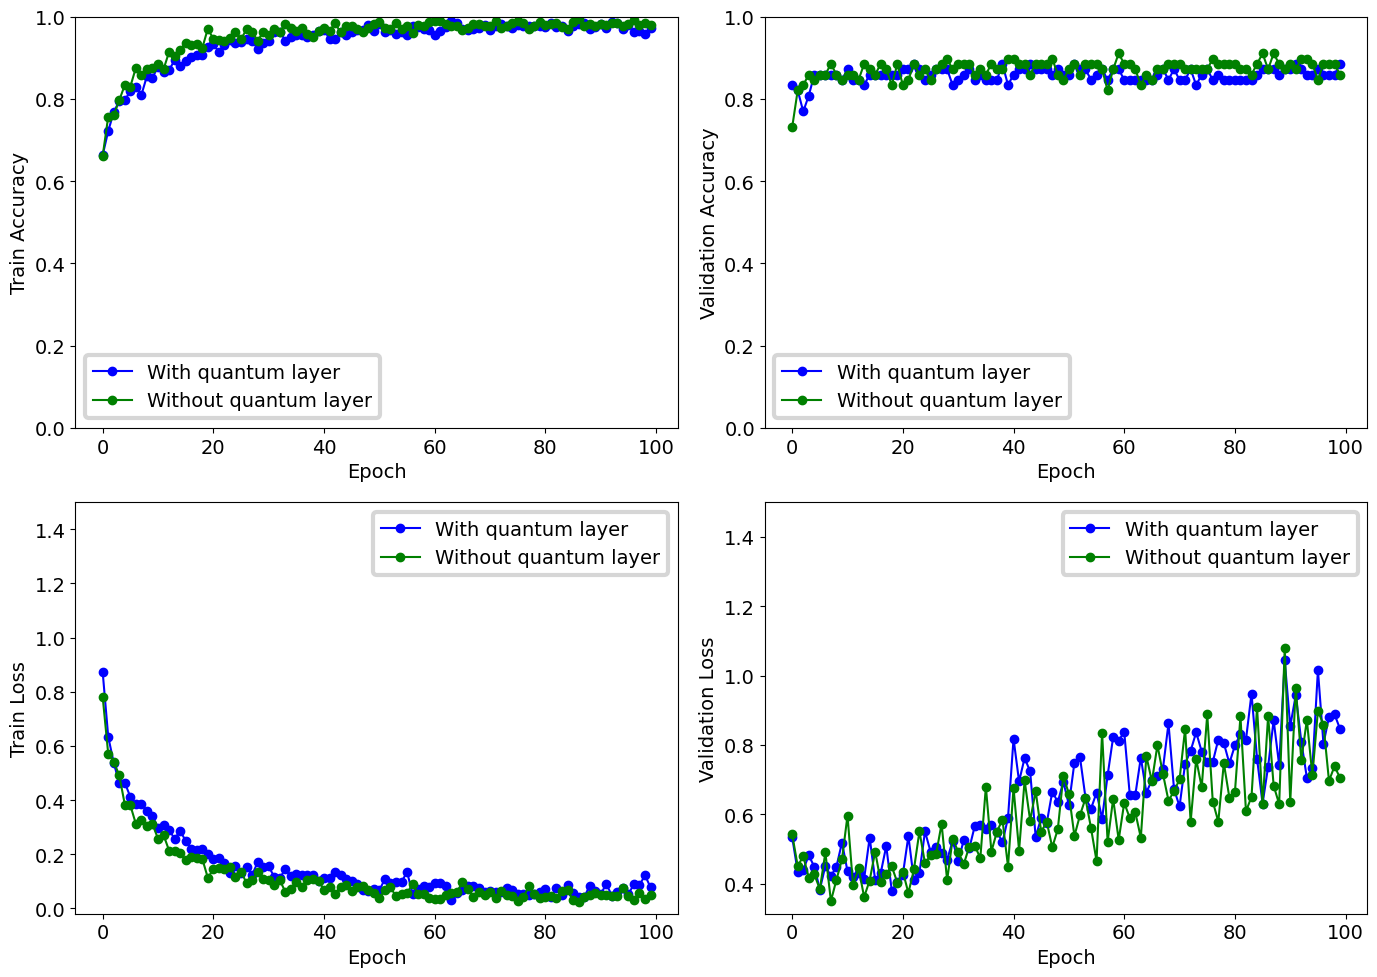

In [226]:
import matplotlib.pyplot as plt

# plt.style.use("seaborn")
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0, 1].plot(q_history.history["val_binary_accuracy"], "-ob", label="With quantum layer")
ax[0, 1].plot(c_history.history["val_binary_accuracy"], "-og", label="Without quantum layer")
ax[0, 1].set_ylabel("Validation Accuracy")
ax[0, 1].set_ylim([0, 1],)
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].legend()

ax[0, 0].plot(q_history.history["binary_accuracy"], "-ob", label="With quantum layer")
ax[0, 0].plot(c_history.history["binary_accuracy"], "-og", label="Without quantum layer")
ax[0, 0].set_ylabel("Train Accuracy")
ax[0, 0].set_ylim([0, 1],)
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].legend()

ax[1, 1].plot(q_history.history["val_loss"], "-ob", label="With quantum layer")
ax[1, 1].plot(c_history.history["val_loss"], "-og", label="Without quantum layer")
ax[1, 1].set_ylabel("Validation Loss")
ax[1, 1].set_ylim(top=1.5)
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].legend()

ax[1, 0].plot(q_history.history["loss"], "-ob", label="With quantum layer")
ax[1, 0].plot(c_history.history["loss"], "-og", label="Without quantum layer")
ax[1, 0].set_ylabel("Train Loss")
ax[1, 0].set_ylim(top=1.5)
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].legend()

plt.tight_layout()
plt.show()

In [227]:
q_predictions = q_model.predict(q_test_images) # qunatum pred
c_predictions = c_model.predict(test_imgs_tf) # classical pred


print(f"\n Quantum results with {q_model.count_params()} params \n")
q_fpr, q_tpr, q_threshold = roc_curve(test_labels_tf, q_predictions)
auc = roc_auc_score(test_labels_tf, q_predictions)  
print("AUC:", auc)
f1 = f1_score(test_labels_tf, np.round(q_predictions))
print('F1_Score:', f1)
acc = accuracy_score(test_labels_tf, np.round(q_predictions))
print('ACC:', acc)

print(f"\n Classical results with {c_model.count_params()} params \n")
fpr, tpr, threshold = roc_curve(test_labels_tf, c_predictions)
auc_c = roc_auc_score(test_labels_tf, c_predictions)  
print("AUC:", auc_c)
f1_c = f1_score(test_labels_tf, np.round(c_predictions))
print('F1_Score:', f1_c)
acc_c = accuracy_score(test_labels_tf, np.round(c_predictions))
print('ACC:', acc_c)

5/5 [==============================] - 0s 3ms/step

 Quantum results with 30081 params 

AUC: 0.8788638262322473
F1_Score: 0.9029535864978903
ACC: 0.8525641025641025

 Classical results with 5599 params 

AUC: 0.8717627401837929
F1_Score: 0.8583690987124464
ACC: 0.7884615384615384


/tmp/ipykernel_453600/1588263387.py:10: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,2,1)


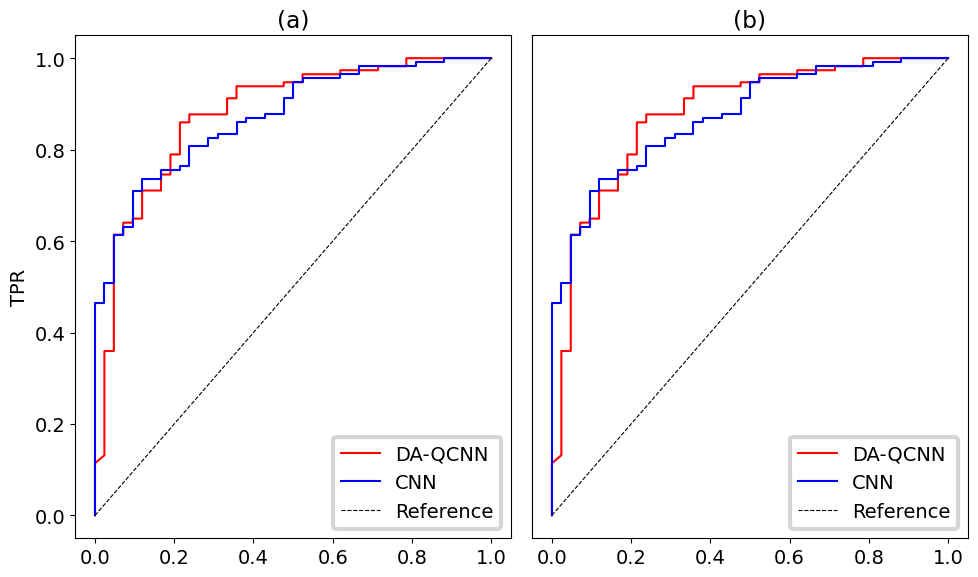

In [228]:
### MAYBE ONE COULD USE THIS KIND OF PLOT FOR TWO DATA SETS

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(10, 6))
plt.text(0.5, -0.15, 'FPR', ha='center')
plt.axis('off')
plt.xticks([])
plt.yticks([])

plt.subplot(1,2,1)
plt.plot(q_fpr, q_tpr, label='DA-QCNN', color='red')
plt.plot(fpr, tpr, label='CNN', color='blue')
plt.plot([0, 1], [0, 1], '--', label='Reference', linewidth=0.8, color="black")
plt.ylabel('TPR')
plt.title("(a)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(q_fpr, q_tpr, label='DA-QCNN', color='red')
plt.plot(fpr, tpr, label='CNN', color='blue')
plt.plot([0, 1], [0, 1], '--', label='Reference', linewidth=0.8, color="black")
plt.legend()
plt.title("(b)")
plt.yticks([]) 

plt.tight_layout()

plt.savefig('roc_curves.pdf')
plt.show()


# 2 Outputs

In [176]:
def create_model(learning_rate=0.0001, activation='relu', batch_size=4, dropout=0.3):
    model = Sequential([
        Conv2D(32, (2, 2), strides=2, activation='relu', input_shape=(27, 27, 16)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (2, 2), activation='relu'),  # Nueva capa Conv2D
        Dropout(dropout),
        Flatten(),
        Dropout(dropout),
        Dense(2, activation="softmax")
    ])

    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

In [177]:
learning_rate = 0.0005
batch_size = 4
dropout = 0.55
model = create_model(learning_rate=learning_rate, batch_size=batch_size, dropout=dropout)

In [178]:
history = model.fit(
    q_train_images,
    train_labels_tf,
    validation_data=(q_val_images, val_labels_tf),
    batch_size=batch_size,
    epochs=100,
    verbose=2,
)

Epoch 1/100
137/137 - 1s - loss: 0.5961 - accuracy: 0.7033 - val_loss: 0.5424 - val_accuracy: 0.7308 - 754ms/epoch - 6ms/step
Epoch 2/100
137/137 - 0s - loss: 0.5471 - accuracy: 0.7381 - val_loss: 0.5246 - val_accuracy: 0.7821 - 427ms/epoch - 3ms/step
Epoch 3/100
137/137 - 0s - loss: 0.5355 - accuracy: 0.7381 - val_loss: 0.5090 - val_accuracy: 0.7949 - 460ms/epoch - 3ms/step
Epoch 4/100
137/137 - 0s - loss: 0.5278 - accuracy: 0.7308 - val_loss: 0.4923 - val_accuracy: 0.7436 - 476ms/epoch - 3ms/step
Epoch 5/100
137/137 - 0s - loss: 0.5050 - accuracy: 0.7527 - val_loss: 0.4792 - val_accuracy: 0.7949 - 452ms/epoch - 3ms/step
Epoch 6/100
137/137 - 0s - loss: 0.4966 - accuracy: 0.7637 - val_loss: 0.4680 - val_accuracy: 0.8077 - 457ms/epoch - 3ms/step
Epoch 7/100
137/137 - 0s - loss: 0.4867 - accuracy: 0.7857 - val_loss: 0.4574 - val_accuracy: 0.7949 - 469ms/epoch - 3ms/step
Epoch 8/100
137/137 - 0s - loss: 0.4768 - accuracy: 0.7894 - val_loss: 0.4352 - val_accuracy: 0.8205 - 458ms/epoch - 3

Epoch 66/100
137/137 - 0s - loss: 0.1858 - accuracy: 0.9249 - val_loss: 0.3849 - val_accuracy: 0.8846 - 443ms/epoch - 3ms/step
Epoch 67/100
137/137 - 0s - loss: 0.1552 - accuracy: 0.9432 - val_loss: 0.4013 - val_accuracy: 0.8462 - 389ms/epoch - 3ms/step
Epoch 68/100
137/137 - 0s - loss: 0.2045 - accuracy: 0.9103 - val_loss: 0.3549 - val_accuracy: 0.8590 - 341ms/epoch - 2ms/step
Epoch 69/100
137/137 - 0s - loss: 0.1468 - accuracy: 0.9505 - val_loss: 0.4292 - val_accuracy: 0.8718 - 365ms/epoch - 3ms/step
Epoch 70/100
137/137 - 0s - loss: 0.1887 - accuracy: 0.9341 - val_loss: 0.3783 - val_accuracy: 0.8718 - 356ms/epoch - 3ms/step
Epoch 71/100
137/137 - 0s - loss: 0.1713 - accuracy: 0.9304 - val_loss: 0.4018 - val_accuracy: 0.8590 - 379ms/epoch - 3ms/step
Epoch 72/100
137/137 - 0s - loss: 0.1818 - accuracy: 0.9286 - val_loss: 0.4081 - val_accuracy: 0.8462 - 365ms/epoch - 3ms/step
Epoch 73/100
137/137 - 0s - loss: 0.1483 - accuracy: 0.9414 - val_loss: 0.3701 - val_accuracy: 0.8718 - 452ms/e

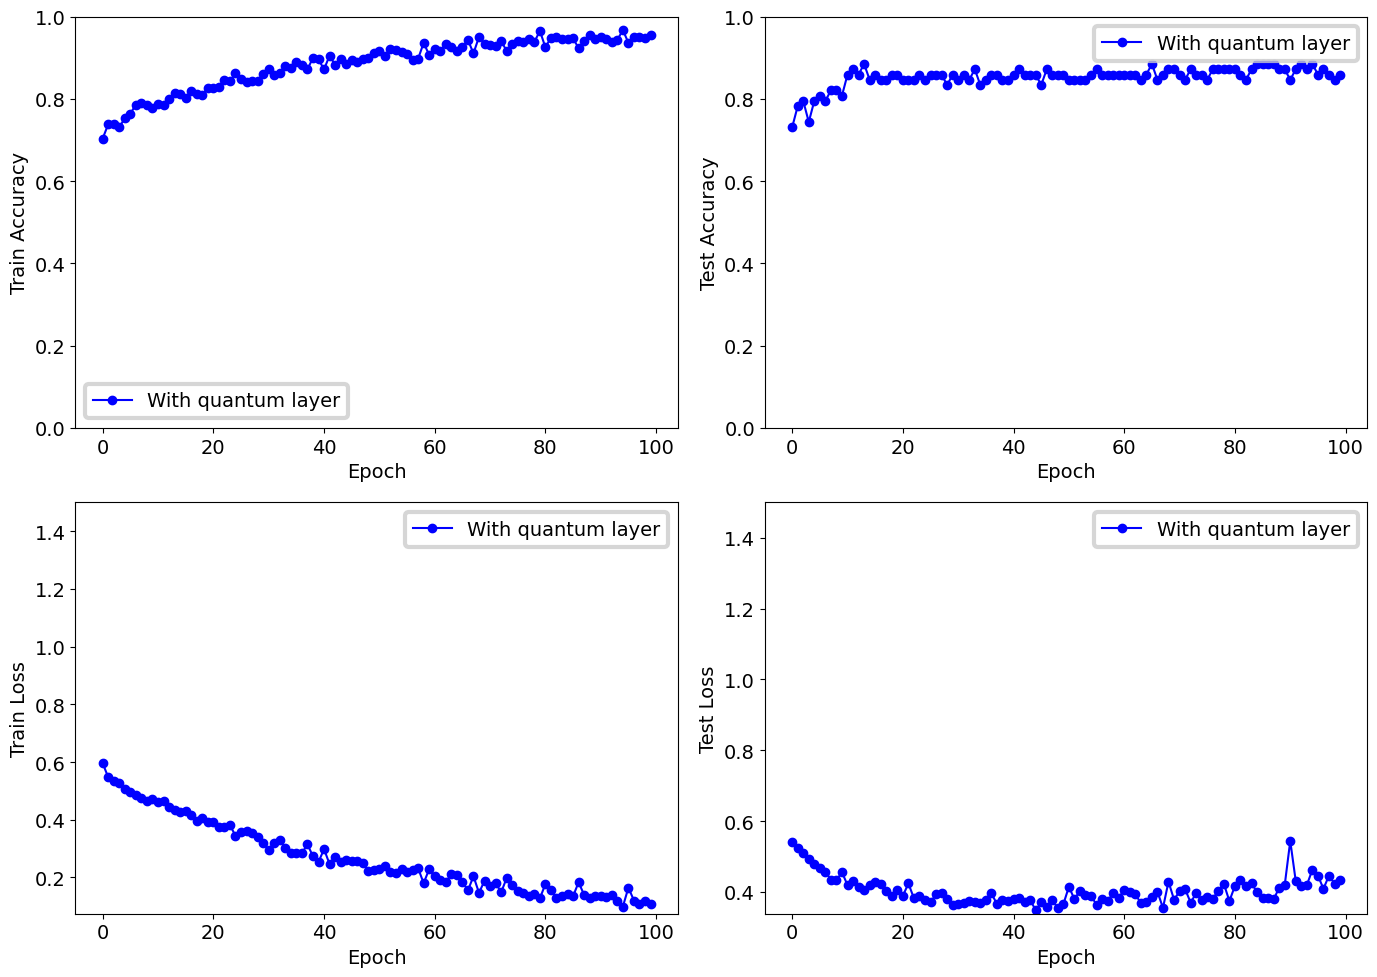

In [179]:
# plt.style.use("seaborn")
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0, 1].plot(history.history["val_accuracy"], "-ob", label="With quantum layer")
ax[0, 1].set_ylabel("Test Accuracy")
ax[0, 1].set_ylim([0, 1],)
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].legend()

ax[0, 0].plot(history.history["accuracy"], "-ob", label="With quantum layer")
ax[0, 0].set_ylabel("Train Accuracy")
ax[0, 0].set_ylim([0, 1],)
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].legend()

ax[1, 1].plot(history.history["val_loss"], "-ob", label="With quantum layer")
ax[1, 1].set_ylabel("Test Loss")
ax[1, 1].set_ylim(top=1.5)
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].legend()

ax[1, 0].plot(history.history["loss"], "-ob", label="With quantum layer")
ax[1, 0].set_ylabel("Train Loss")
ax[1, 0].set_ylim(top=1.5)
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].legend()

plt.tight_layout()
plt.show()

In [180]:
q_predictions = model.predict(q_test_images) # qunatum pred

5/5 [==============================] - 0s 3ms/step


In [181]:
fprq, tprq, threshold = roc_curve(test_labels_tf, q_predictions[:,1])

# AUC:
auc = roc_auc_score(test_labels_tf, q_predictions[:,1])  
 
print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(test_labels_tf, np.round(q_predictions[:,1]))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(test_labels_tf, np.round(q_predictions[:,1]))
print('ACC:', acc)

AUC: 0.8736424394319131
F1_Score: 0.9016393442622951
ACC: 0.8461538461538461


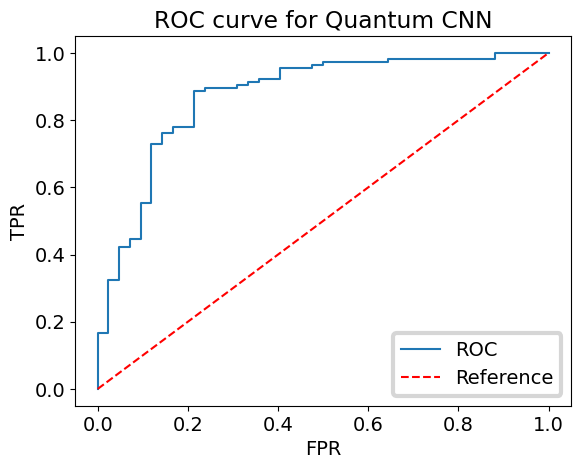

In [201]:
# Trazar la curva ROC
plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Quantum CNN')
plt.legend()
plt.show()

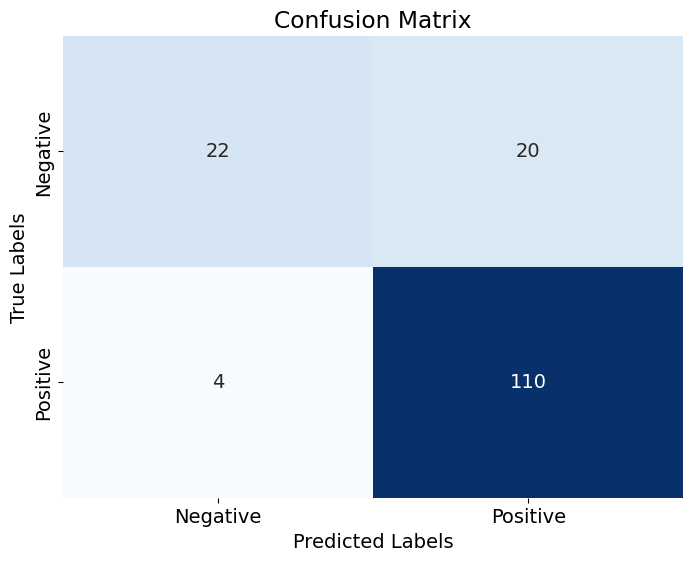

In [183]:
# Calcular la matriz de confusión
conf_matrix = confusion_matrix(test_labels_tf, np.round(q_predictions[:, 1]))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Let's train the same model 100 times and save results each time

In [206]:
def AUC_and_ACC(data = test_labels_tf, pred = q_predictions[:,1]):
    auc = roc_auc_score(data, pred)
    acc = accuracy_score(data, np.round(pred))
    return auc, acc

In [207]:
learning_rate = 0.0005
batch_size = 4
dropout = 0.55

In [208]:
train_ACC = []
train_AUC = []

test_ACC = []
test_AUC = []

val_ACC = []
val_AUC = []

model_weights = []  # save weights

for i in range(200):
    model = create_model(learning_rate=learning_rate, batch_size=batch_size, dropout=dropout)
    
    history = model.fit(
        q_train_images,
        train_labels_tf,
        validation_data=(q_val_images, val_labels_tf),
        batch_size=batch_size,
        epochs=100,
        verbose=100,
    )
    
    # Guardar los pesos del modelo
    model_weights.append(model.get_weights())
    
    q_predictions_train = model.predict(q_train_images)
    auc_train, acc_train = AUC_and_ACC(data=train_labels_tf, pred=q_predictions_train[:,1])
    train_AUC.append(auc_train)
    train_ACC.append(acc_train)
    
    q_predictions_test = model.predict(q_test_images)
    auc_test, acc_test = AUC_and_ACC(data=test_labels_tf, pred=q_predictions_test[:,1])
    test_AUC.append(auc_test)
    test_ACC.append(acc_test)
    
    q_predictions_val = model.predict(q_val_images)
    auc_val, acc_val = AUC_and_ACC(data=val_labels_tf, pred=q_predictions_val[:,1])
    val_AUC.append(auc_val)
    val_ACC.append(acc_val)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49

Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49

...

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49

Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



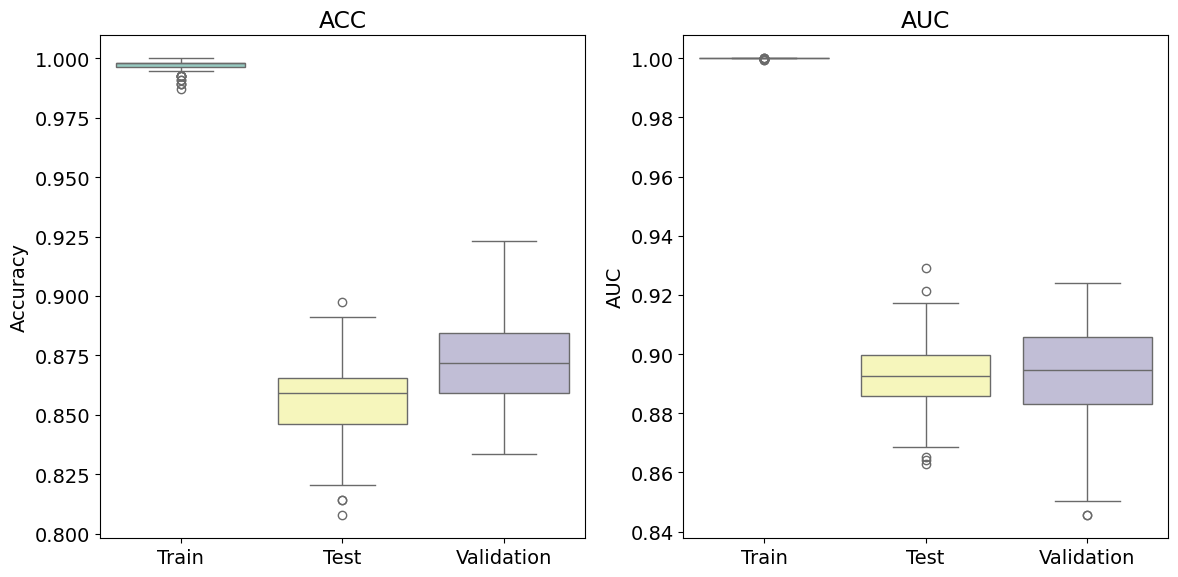

In [209]:
# Crear los box plots
plt.figure(figsize=(12, 6))

# Box plot para ACC
plt.subplot(1, 2, 1)
sns.boxplot(data=[train_ACC, test_ACC, val_ACC], palette="Set3")
plt.title('ACC')
plt.xticks([0, 1, 2], ['Train', 'Test', 'Validation'])
plt.ylabel('Accuracy')

# Box plot para AUC
plt.subplot(1, 2, 2)
sns.boxplot(data=[train_AUC, test_AUC, val_AUC], palette="Set3")
plt.title('AUC')
plt.xticks([0, 1, 2], ['Train', 'Test', 'Validation'])
plt.ylabel('AUC')

# Ajustes estéticos adicionales
plt.tight_layout()

# Mostrar los box plots
plt.show()

In [210]:
print('The median of the AUC: \nTrain: ',np.median(train_AUC), '\nTest: ',np.median(test_AUC), '\nValidation: ',np.median(val_AUC))
print('The median of the ACC: \nTrain: ',np.median(train_ACC), '\nTest: ',np.median(test_ACC), '\nValidation: ',np.median(val_ACC))

The median of the AUC: 
Train:  1.0 
Test:  0.8924394319131161 
Validation:  0.894736842105263
The median of the ACC: 
Train:  0.9981684981684982 
Test:  0.8589743589743589 
Validation:  0.8717948717948718


### Best model:

In [215]:
best_model_index = np.argmax(test_AUC) # save index
best_model_weights = model_weights[best_model_index] # best weights

# set weights on the model
best_model = create_model(learning_rate=learning_rate, batch_size=batch_size, dropout=dropout)
best_model.set_weights(best_model_weights)

In [216]:
# predictions
best_pred = best_model.predict(q_test_images)

5/5 [==============================] - 0s 2ms/step


In [217]:
fprq, tprq, threshold = roc_curve(test_labels_tf, best_pred[:,1])

# AUC:
auc = roc_auc_score(test_labels_tf, best_pred[:,1])  
 
print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(test_labels_tf, np.round(best_pred[:,1]))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(test_labels_tf, np.round(best_pred[:,1]))
print('ACC:', acc)

AUC: 0.9291979949874687
F1_Score: 0.9310344827586206
ACC: 0.8974358974358975


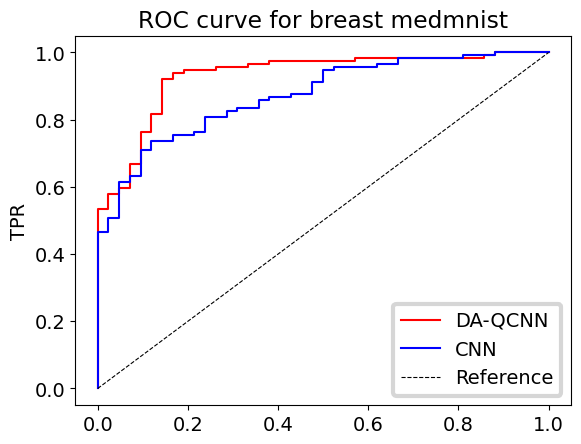

In [220]:
plt.plot(fprq, tprq, label='DA-QCNN', color='red')
plt.plot(fpr, tpr, label='CNN', color='blue')
plt.plot([0, 1], [0, 1], '--', label='Reference', linewidth=0.8, color="black")
plt.ylabel('TPR')
plt.title("ROC curve for breast medmnist")
plt.legend()
plt.show()

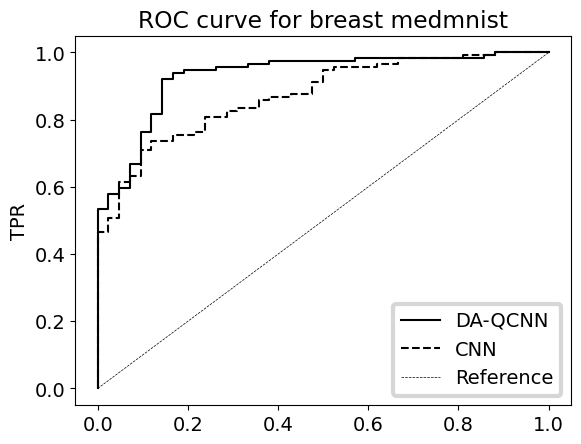

In [252]:
plt.plot(fprq, tprq, label='DA-QCNN', color='black', linestyle='-')
plt.plot(fpr, tpr, label='CNN', color='black', linestyle='--')
plt.plot([0, 1], [0, 1], '--', label='Reference', linewidth=0.5, color="black")
plt.ylabel('TPR')
plt.title("ROC curve for breast medmnist")
plt.legend()
plt.show()

# Classical model:

In [ ]:
learning_rate = 0.0005
batch_size = 4
dropout = 0.55

In [231]:
c_train_ACC = []
c_train_AUC = []

c_test_ACC = []
c_test_AUC = []

c_val_ACC = []
c_val_AUC = []

c_model_weights = []  # save weights

for i in range(200):
    model = CNN(learning_rate=learning_rate)
    
    history = model.fit(
        train_imgs_tf,
        train_labels_tf,
        validation_data=(val_imgs_tf, val_labels_tf),
        batch_size=batch_size,
        epochs=100,
        verbose=100,
    )
    
    # Guardar los pesos del modelo
    c_model_weights.append(model.get_weights())
    
    predictions_train = model.predict(train_imgs_tf)
    auc_train, acc_train = AUC_and_ACC(data=train_labels_tf, pred=predictions_train[:,1])
    c_train_AUC.append(auc_train)
    c_train_ACC.append(acc_train)
    
    predictions_test = model.predict(test_imgs_tf)
    auc_test, acc_test = AUC_and_ACC(data=test_labels_tf, pred=predictions_test[:,1])
    c_test_AUC.append(auc_test)
    c_test_ACC.append(acc_test)
    
    predictions_val = model.predict(val_imgs_tf)
    auc_val, acc_val = AUC_and_ACC(data=val_labels_tf, pred=predictions_val[:,1])
    c_val_AUC.append(auc_val)
    c_val_ACC.append(acc_val)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 3ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49

Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49

...

Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] 

3/3 [==============================] - 0s 3ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/

Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37

Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 79/100
Epoch 80/100
Epoch 81/100
Epoch 82/100
Epoch 83/100
Epoch 84/100
Epoch 85/100
Epoch 86/100
Epoch 87/100
Epoch 88/100
Epoch 89/100
Epoch 90/100
Epoch 91/100
Epoch 92/100
Epoch 93/100
Epoch 94/100
Epoch 95/100
Epoch 96/100
Epoch 97/100
Epoch 98/100
Epoch 99/100
Epoch 100/100
3/3 [==============================] 

3/3 [==============================] - 0s 2ms/step
Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/

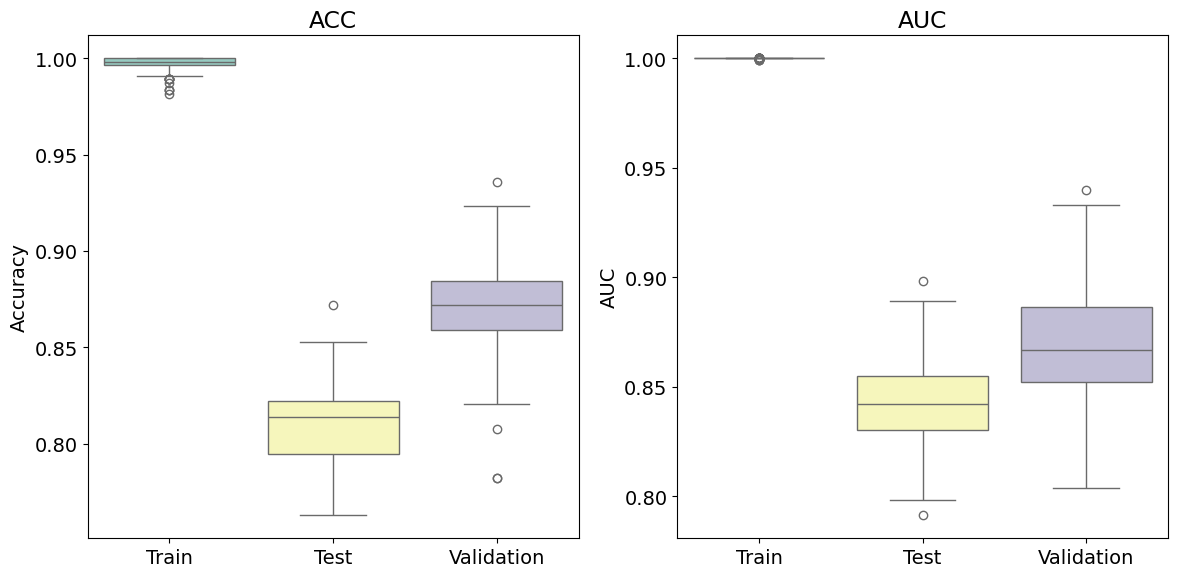

In [234]:
# Crear los box plots
plt.figure(figsize=(12, 6))

# Box plot para ACC
plt.subplot(1, 2, 1)
sns.boxplot(data=[c_train_ACC, c_test_ACC, c_val_ACC], palette="Set3")
plt.title('ACC')
plt.xticks([0, 1, 2], ['Train', 'Test', 'Validation'])
plt.ylabel('Accuracy')

# Box plot para AUC
plt.subplot(1, 2, 2)
sns.boxplot(data=[c_train_AUC, c_test_AUC, c_val_AUC], palette="Set3")
plt.title('AUC')
plt.xticks([0, 1, 2], ['Train', 'Test', 'Validation'])
plt.ylabel('AUC')

# Ajustes estéticos adicionales
plt.tight_layout()

# Mostrar los box plots
plt.show()

In [235]:
print('The median of the AUC: \nTrain: ',np.median(c_train_AUC), '\nTest: ',np.median(c_test_AUC), '\nValidation: ',np.median(c_val_AUC))
print('The median of the ACC: \nTrain: ',np.median(c_train_ACC), '\nTest: ',np.median(c_test_ACC), '\nValidation: ',np.median(c_val_ACC))

The median of the AUC: 
Train:  1.0 
Test:  0.842000835421888 
Validation:  0.866750208855472
The median of the ACC: 
Train:  0.9981684981684982 
Test:  0.8141025641025641 
Validation:  0.8717948717948718


# Comparison Classical vs DA-QC

In [239]:
df_acc = pd.DataFrame()
# Crear DataFrame Accuracy
df_acc['Model'] = ['Classic']*len(c_test_ACC) + ['Quantum']*len(test_ACC)
df_acc['ACC'] = c_test_ACC + test_ACC

df_auc = pd.DataFrame()
# crear df AUC
df_auc['Model'] = ['Classic']*len(c_test_AUC) + ['Quantum']*len(test_AUC)
df_auc['AUC'] = c_test_AUC + test_AUC

/tmp/ipykernel_453600/950699990.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='ACC', data=df_acc, palette="colorblind", linewidth=1.2)
/tmp/ipykernel_453600/950699990.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='AUC', data=df_auc, palette="colorblind", linewidth=1.2)


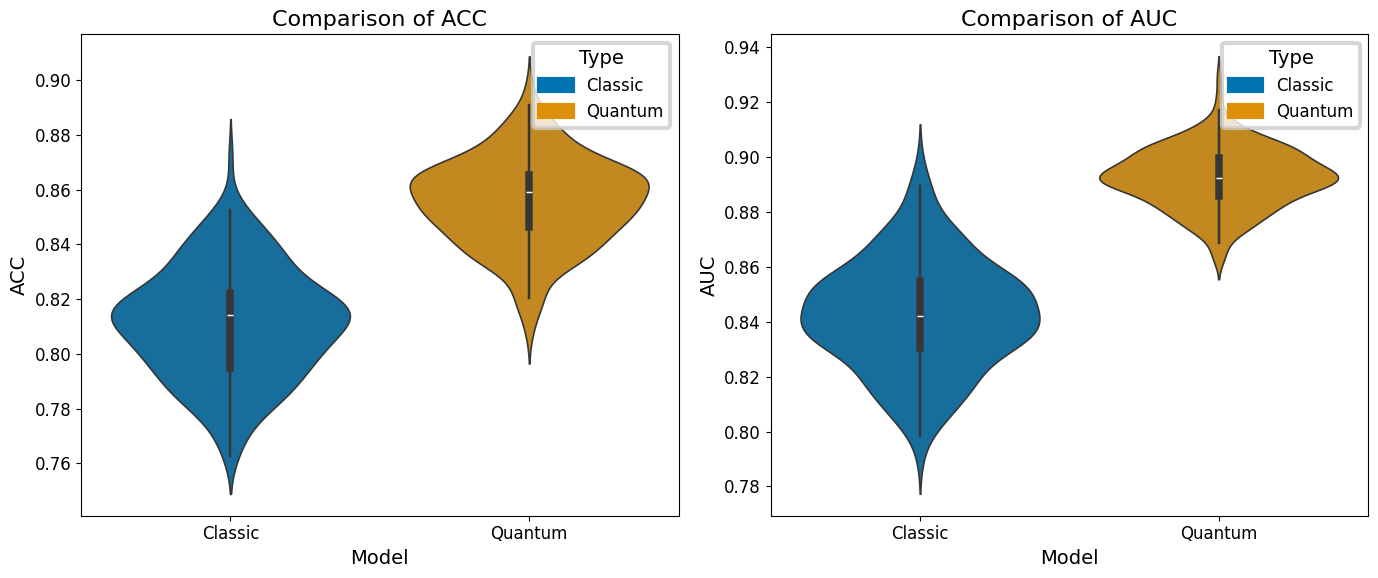

In [246]:
# Plot with Seaborn
plt.figure(figsize=(14, 6))

# ACC plot
plt.subplot(1, 2, 1)
sns.violinplot(x='Model', y='ACC', data=df_acc, palette="colorblind", linewidth=1.2)
plt.title('Comparison of ACC', fontsize=16)
plt.ylabel('ACC', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Custom legend for ACC
legend_patch = [mpatches.Patch(color=sns.color_palette("colorblind")[0], label='Classic'),
                mpatches.Patch(color=sns.color_palette("colorblind")[1], label='Quantum')]
plt.legend(handles=legend_patch, title='Type', fontsize=12)

# AUC plot
plt.subplot(1, 2, 2)
sns.violinplot(x='Model', y='AUC', data=df_auc, palette="colorblind", linewidth=1.2)
plt.title('Comparison of AUC', fontsize=16)
plt.ylabel('AUC', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Custom legend for AUC
plt.legend(handles=legend_patch, title='Type', fontsize=12)

plt.tight_layout()
plt.show()